In [1]:
# from google.colab import drive
# drive.mount('/content/drive')
# %cd /content/drive/MyDrive/Studia-II/Uczenie-Maszynowe/Lista7/Zad3

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean

import time

In [3]:
RANDOM_STATE = 2137

np.random.seed(RANDOM_STATE)

In [4]:
def generate_gps_route(route_type, length=30):

    t = np.linspace(0, 10, length)
    noise = np.random.normal(0, 0.2, length) 
    
    if route_type == 'A': 
        x = t + noise
        y = 2.1 * np.sin(2.1 * t) + noise 
        
    elif route_type == 'B':
        x = t + noise
        y = 2 * np.sin(2 * t) + noise
        
    elif route_type == 'C':
        x = t + noise
        y = 1.9 * np.sin(1.9 * t) + noise
        
    return np.column_stack((x, y))

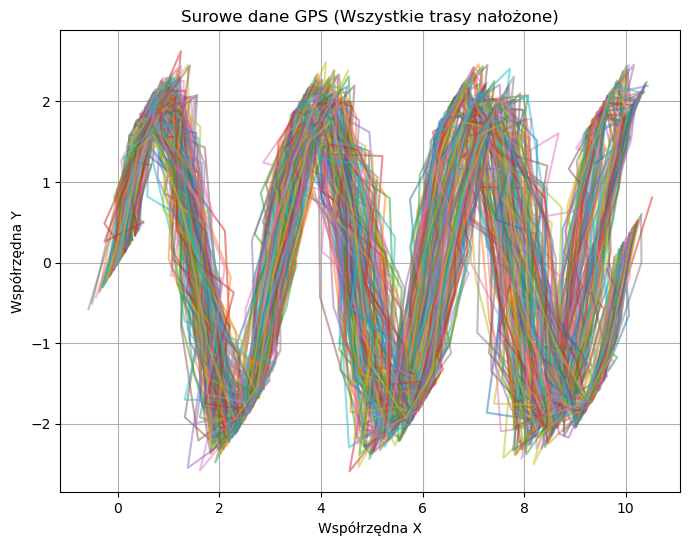

In [5]:
trajectories = []
labels_true = [] 

n_trajectories_per_class = 50

# Generujemy 30 tras (po 10 z każdego typu)
# Każda trasa ma LOSOWĄ długość (od 20 do 50 punktów), 
# żeby symulować różną prędkość rowerzystów!

for _ in range(n_trajectories_per_class):
    l = np.random.randint(20, 50)
    trajectories.append(generate_gps_route('A', length=l))
    labels_true.append(0)

for _ in range(n_trajectories_per_class):
    l = np.random.randint(20, 50)
    trajectories.append(generate_gps_route('B', length=l))
    labels_true.append(1)

for _ in range(n_trajectories_per_class):
    l = np.random.randint(20, 50)
    trajectories.append(generate_gps_route('C', length=l))
    labels_true.append(2)

plt.figure(figsize=(8, 6))
for traj in trajectories:
    plt.plot(traj[:, 0], traj[:, 1], alpha=0.5)
plt.title("Surowe dane GPS (Wszystkie trasy nałożone)")
plt.xlabel("Współrzędna X")
plt.ylabel("Współrzędna Y")
plt.grid(True)
plt.show()

In [6]:
def compute_dtw(seq1, seq2):
    """
    Oblicza odległość DTW między dwiema trasami.
    Pozwala porównać trasy o różnej liczbie punktów.
    """
    n, m = len(seq1), len(seq2)
    
    # Macierz kosztów (inicjalizacja nieskończonością)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = euclidean(seq1[i-1], seq2[j-1])
            
            last_min = np.min([dtw_matrix[i-1, j],    # Insertion (rozciąganie)
                               dtw_matrix[i, j-1],    # Deletion (ściskanie)
                               dtw_matrix[i-1, j-1]]) # Match (dopasowanie)
            
            dtw_matrix[i, j] = cost + last_min
            
    return dtw_matrix[n, m]

Czas: 63.42 s


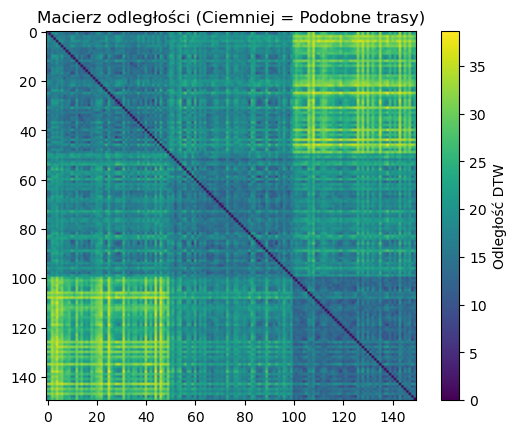

In [7]:

num_traj = len(trajectories)
dist_matrix = np.zeros((num_traj, num_traj))

start = time.time()

for i in range(num_traj):
    for j in range(i + 1, num_traj):
        d = compute_dtw(trajectories[i], trajectories[j])
        dist_matrix[i, j] = d
        dist_matrix[j, i] = d 

print(f"Czas: {time.time() - start:.2f} s")

plt.imshow(dist_matrix, cmap='viridis')
plt.colorbar(label='Odległość DTW')
plt.title("Macierz odległości (Ciemniej = Podobne trasy)")
plt.show()

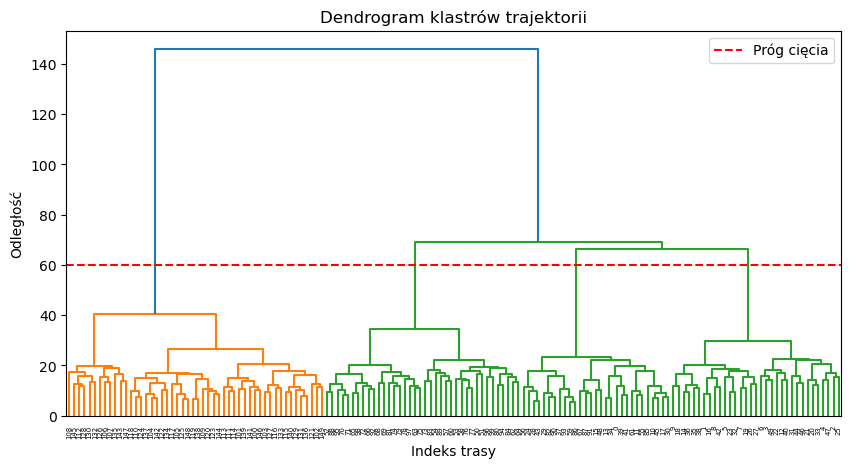

Etykiety klastrów: [3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 2 2 2 2 2 3 3 2 2 3 2 3 2 2 2 2 2 3 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 3 2 2 3 3 3 2 2 3 3 2 3 2 2 2 2 2 2 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]


In [ ]:
# Grupowanie hierarchiczne (Metoda Warda)
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

# Konwersja macierzy do formatu scipy
condensed_dist = squareform(dist_matrix)

# Tworzenie drzewa połączeń (linkage)
Z = linkage(condensed_dist, method='ward')

# Rysowanie dendrogramu
plt.figure(figsize=(10, 5))
dendrogram(Z)

plt.title("Dendrogram klastrów trajektorii")
plt.xlabel("Indeks trasy")
plt.ylabel("Odległość")
plt.axhline(y=60, c='r', ls='--', label='Próg cięcia')
plt.legend()
plt.show()

# Automatyczne wycięcie 3 klastrów (bo tyle typów wygenerowaliśmy)
k = 3
labels_pred = fcluster(Z, t=k, criterion='maxclust')
print(f"Etykiety klastrów: {labels_pred}")

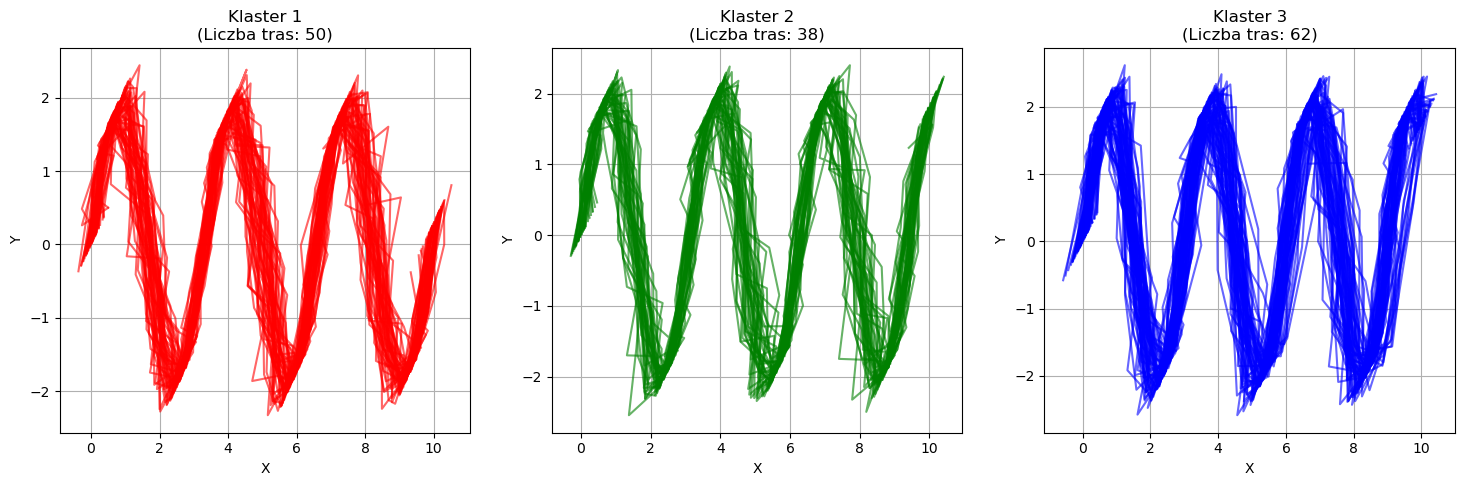

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ["Klaster 1", "Klaster 2", "Klaster 3"]
colors = ['r', 'g', 'b']

unique_labels = np.unique(labels_pred)

for i, label in enumerate(unique_labels):
    ax = axes[i]
    
    indices = np.where(labels_pred == label)[0]
    
    for idx in indices:
        t = trajectories[idx]
        ax.plot(t[:, 0], t[:, 1], c=colors[i], alpha=0.6)
        
    ax.set_title(f"Klaster {label}\n(Liczba tras: {len(indices)})")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(True)

plt.show()

Adjusted Rand Index (ARI): 0.7880


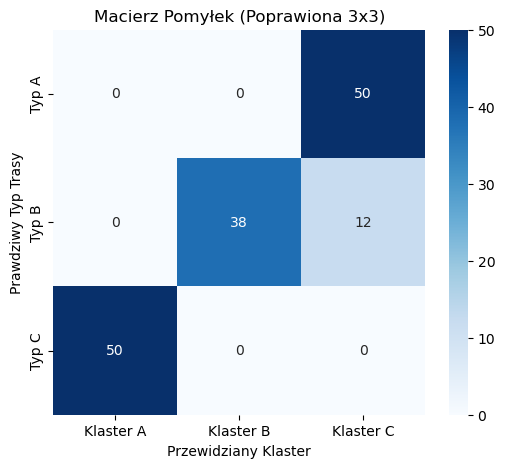

In [11]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, confusion_matrix
import seaborn as sns

labels_pred_corrected = labels_pred - 1 

cm = confusion_matrix(labels_true, labels_pred_corrected)
ari = adjusted_rand_score(labels_true, labels_pred_corrected)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Klaster A', 'Klaster B', 'Klaster C'], 
            yticklabels=['Typ A', 'Typ B', 'Typ C'])
plt.xlabel("Przewidziany Klaster")
plt.ylabel("Prawdziwy Typ Trasy")
plt.title("Macierz Pomyłek (Poprawiona 3x3)")
plt.show()

Niby wszystko źle, ale to tylko inna permtuacja wyników, także nawet jest dobrze.

ARI jest istotne

klaster C -> typ A
klaster B -> typ B
klaster A -> typ C

tak był to przyporządkował, 